In [18]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
os.environ["OPENCV_IO_ENABLE_OPENEXR"]="1"
import json

from pprint import pprint
from pysolotools.consumers import Solo
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
# to make ploty render properly
import plotly.io as pio
pio.renderers.default = 'iframe'

In [53]:
def read_img(filename):
    img_path = f"{DATA_PATH}/sequence.0/{filename}"
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img, img_path

def read_exr_img(filename):
    img_path = f"{DATA_PATH}/sequence.0/{filename}"
    img = cv2.imread(img_path, cv2.IMREAD_ANYCOLOR | cv2.IMREAD_ANYDEPTH)
    return img, img_path

In [98]:
def norm_img(img):
    assert len(img.shape) >= 3
    min_of_each_channel = img.reshape(-1, img.shape[-1]).min(axis=0)
    max_of_each_channel = img.reshape(-1, img.shape[-1]).max(axis=0) + 1e-8
    return (img - min_of_each_channel) / (max_of_each_channel - min_of_each_channel)

In [129]:
SOLO_NAME = 'repr_viz'
DATA_DIR = '../output'
DATA_PATH = f'{DATA_DIR}/{SOLO_NAME}'

OUTPUT_PATH = f'./ace/{SOLO_NAME}'
for path in [f'{OUTPUT_PATH}/{dir}' for dir in ['rgb', 'seg', 'depth']]:
    if not os.path.exists(path):
        os.makedirs(path, exist_ok=True)
        print(f'create folder: {path}')

create folder: ./ace/repr_viz/rgb
create folder: ./ace/repr_viz/seg
create folder: ./ace/repr_viz/depth


In [130]:
solo = Solo(DATA_PATH)

In [74]:
json_df = pd.DataFrame()

frame_iter = solo.frames()
frame_idx = 0
total_len = len(list(solo.frame_ids()))

for frame_idx in tqdm(range(total_len)):
    try:
        f = next(frame_iter)
        cap = f.captures[0]
        metrics_df = f.get_metrics_df().set_index('id')
        metadata_df = metrics_df.loc['metadata']
        annotations_df = cap.get_annotations_df().set_index('id')
    
        cam_meta = metadata_df['values'][0]['my_camera_metadata']
    
        filename = f.frame
        img_size = cap.dimension
        rgb_filename = cap.filename
        seg_filename = annotations_df.loc['semantic segmentation', 'filename']
        dep_filename = annotations_df.loc['Depth', 'filename']
        rgb_img, _ = read_img(rgb_filename)
        seg_img, _ = read_img(seg_filename)
        dep_img, _ = read_dep_img(dep_filename)
        dep_img *= 1000  # scale from 1m to 1mm
        
        meta = pd.DataFrame({
            '#image_file': filename,
            'position.x[m]': cam_meta['position'][0],
            'position.y[m]': cam_meta['position'][1],
            'position.z[m]': cam_meta['position'][2],
            'quaternion.w': cam_meta['rotationQuaternion'][0],
            'quaternion.x': cam_meta['rotationQuaternion'][1],
            'quaternion.y': cam_meta['rotationQuaternion'][2],
            'quaternion.z': cam_meta['rotationQuaternion'][3],
            'focal_length': cam_meta['focalLength'],
            # 'img_size.w': img_size[0],
            # 'img_size.h': img_size[1],
        }, index=[filename])
        
        json_df = pd.concat((json_df, meta), axis=0)
    
        cv2.imwrite(f'{OUTPUT_PATH}/rgb/{filename}.png', rgb_img)
        cv2.imwrite(f'{OUTPUT_PATH}/seg/{filename}.png', seg_img)
        cv2.imwrite(f'{OUTPUT_PATH}/depth/{filename}.tiff', dep_img)
    except StopIteration:
        break
    except:
        print(f'{frame_idx} is skipped')
        continue

json_df.to_csv(f'{OUTPUT_PATH}/gt.txt', index=False)

print(f'total {frame_idx} successful frames!')

  0%|          | 0/10 [00:00<?, ?it/s]

total 9 successful frames!


## Testing

In [75]:
f = next(solo.frames())
cap = f.captures[0]
metrics_df = f.get_metrics_df().set_index('id')
metadata_df = metrics_df.loc['metadata']
annotations_df = cap.get_annotations_df().set_index('id')

In [76]:
cam_meta = metadata_df['values'][0]['my_camera_metadata']
cam_meta

{'rotationQuaternion': [0.275591075, -0.00624308549, 0.02177014, 0.9610082],
 'localRotationQuaternion': [0.275591075,
  -0.00624308549,
  0.02177014,
  0.9610082],
 'position': [-0.4023226, 2.927084, 9.901927],
 'positionLocal': [-0.4023226, 2.927084, 9.901927],
 'focalLength': 31.1548443}

In [141]:
img_size = cap.dimension
rgb_filename = cap.filename
seg_filename = annotations_df.loc['semantic segmentation', 'filename']
ins_filename = annotations_df.loc['instance segmentation', 'filename']
nor_filename = annotations_df.loc['Normal', 'filename']
dep_filename = annotations_df.loc['Depth', 'filename']
scr_filename = annotations_df.loc['PixelPosition', 'filename']
rgb_img, rgb_path = read_img(rgb_filename)
seg_img, seg_path = read_img(seg_filename)
ins_img, ins_path = read_img(ins_filename)
nor_img, nor_path = read_exr_img(nor_filename)
dep_img, dep_path = read_exr_img(dep_filename)
scr_img, scr_path = read_exr_img(scr_filename)

meta = {
    'position.x': cam_meta['position'][0],
    'position.y': cam_meta['position'][1],
    'position.z': cam_meta['position'][2],
    'quaternion.w': cam_meta['rotationQuaternion'][0],
    'quaternion.x': cam_meta['rotationQuaternion'][1],
    'quaternion.y': cam_meta['rotationQuaternion'][2],
    'quaternion.z': cam_meta['rotationQuaternion'][3],
    'focal_length': cam_meta['focalLength'],
    'img_size.w': img_size[0],
    'img_size.h': img_size[1],
    'rgb_filename': rgb_filename,
    'seg_filename': seg_filename,
    'nor_filename': nor_filename,
    'dep_filename': dep_filename,
    'scr_filename': scr_filename,
    'rgb_path': rgb_path,
    'seg_path': seg_path,
    'nor_path': nor_path,
    'dep_path': dep_path,
    'scr_path': scr_path,
}

In [142]:
meta

{'position.x': -0.4023226,
 'position.y': 2.927084,
 'position.z': 9.901927,
 'quaternion.w': -0.2101617,
 'quaternion.x': 0.569917142,
 'quaternion.y': -0.17960076,
 'quaternion.z': -0.7738024,
 'focal_length': 31.1548443,
 'img_size.w': 337.0,
 'img_size.h': 279.0,
 'rgb_filename': 'step8.camera.png',
 'seg_filename': 'step8.camera.semantic segmentation.png',
 'nor_filename': 'step8.camera.Normal.exr',
 'dep_filename': 'step8.camera.Depth.exr',
 'scr_filename': 'step8.camera.PixelPosition.exr',
 'rgb_path': '../output/repr_viz/sequence.0/step8.camera.png',
 'seg_path': '../output/repr_viz/sequence.0/step8.camera.semantic segmentation.png',
 'nor_path': '../output/repr_viz/sequence.0/step8.camera.Normal.exr',
 'dep_path': '../output/repr_viz/sequence.0/step8.camera.Depth.exr',
 'scr_path': '../output/repr_viz/sequence.0/step8.camera.PixelPosition.exr'}

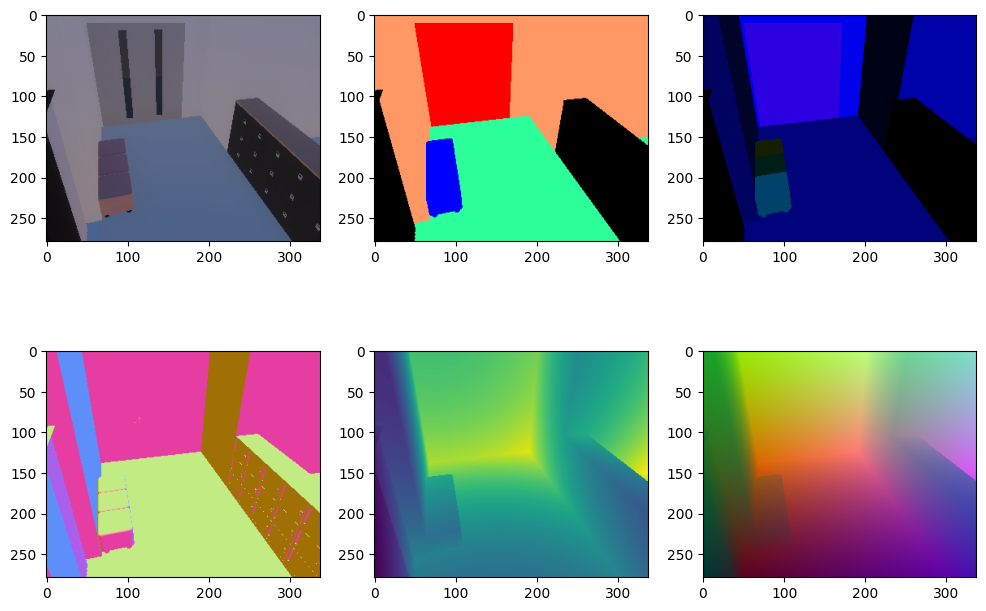

In [143]:
plt.figure(figsize=(12,8))

plt.subplot(231)
plt.imshow(rgb_img)
plt.subplot(232)
plt.imshow(seg_img)
plt.subplot(233)
plt.imshow(ins_img)
plt.subplot(234)
plt.imshow((nor_img))
plt.subplot(235)
plt.imshow(norm_img(dep_img[:,:,-1:]))
plt.subplot(236)
plt.imshow(norm_img(scr_img))

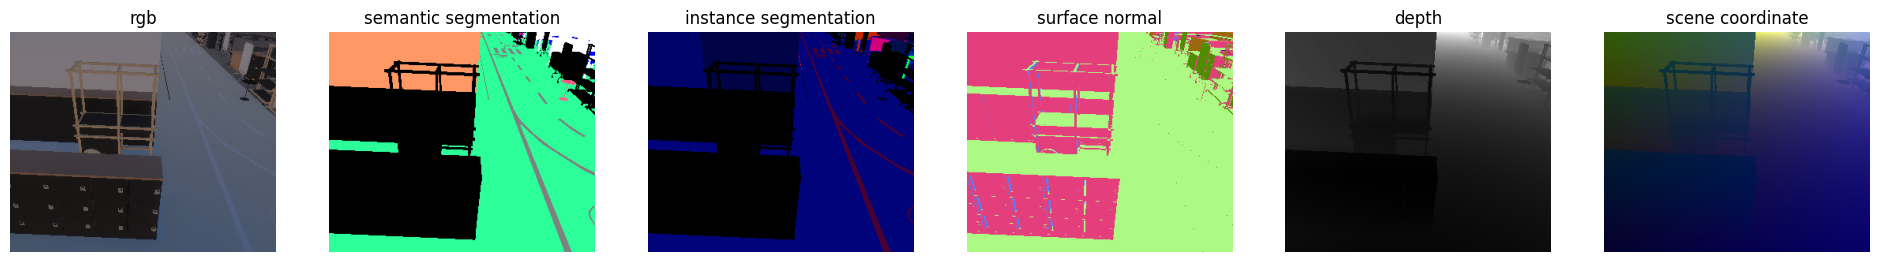

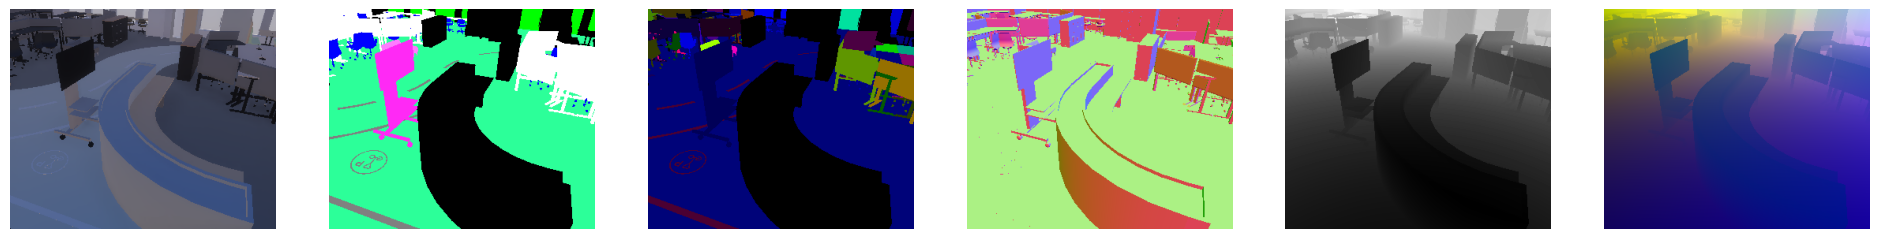

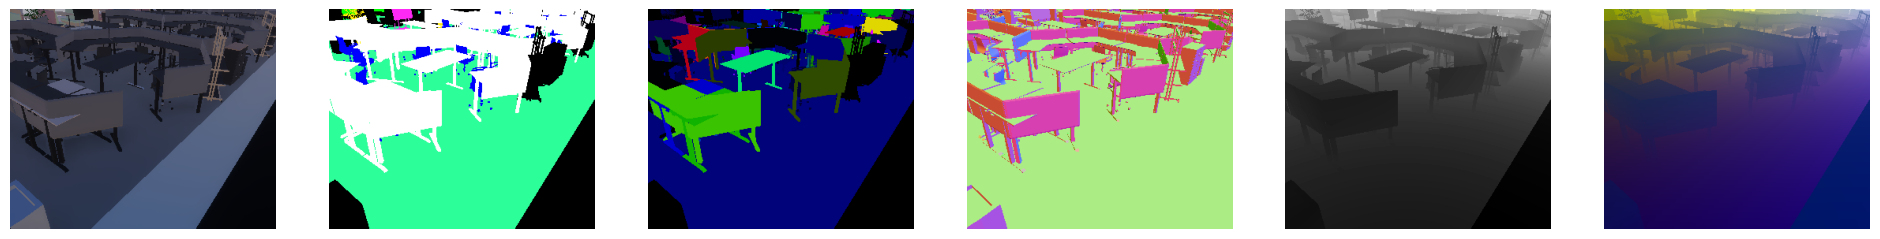

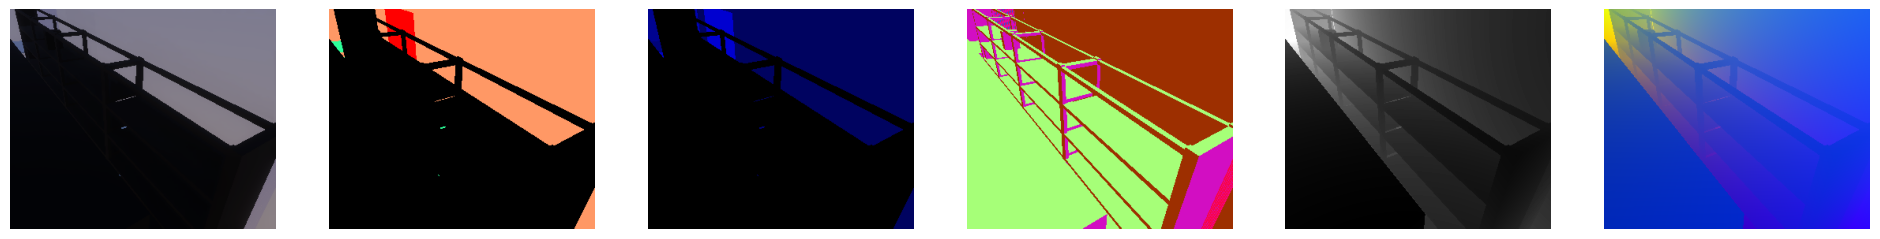

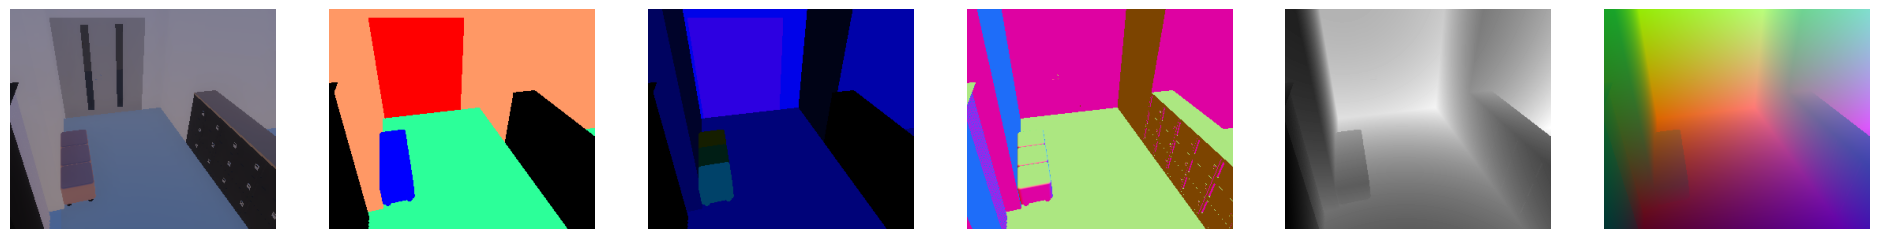

In [145]:
for f in list(solo.frames())[::2]:
    cap = f.captures[0]
    metrics_df = f.get_metrics_df().set_index('id')
    metadata_df = metrics_df.loc['metadata']
    annotations_df = cap.get_annotations_df().set_index('id')
    cam_meta = metadata_df['values'][0]['my_camera_metadata']

    img_size = cap.dimension
    rgb_filename = cap.filename
    seg_filename = annotations_df.loc['semantic segmentation', 'filename']
    ins_filename = annotations_df.loc['instance segmentation', 'filename']
    dep_filename = annotations_df.loc['Depth', 'filename']
    nor_filename = annotations_df.loc['Normal', 'filename']
    scr_filename = annotations_df.loc['PixelPosition', 'filename']
    rgb_img, rgb_path = read_img(rgb_filename)
    seg_img, seg_path = read_img(seg_filename)
    ins_img, ins_path = read_img(ins_filename)
    nor_img, nor_path = read_exr_img(nor_filename)
    dep_img, dep_path = read_exr_img(dep_filename)
    scr_img, scr_path = read_exr_img(scr_filename)

    plt.figure(figsize=(24,6))
    # plt.suptitle(f'frame {f.step}')
    plt.subplot(161)
    plt.axis('off')
    if f.step == 0:
        plt.title('rgb')
    plt.imshow(rgb_img)
    plt.subplot(162)
    plt.axis('off')
    if f.step == 0:
        plt.title('semantic segmentation')
    plt.imshow(seg_img)
    plt.subplot(163)
    plt.axis('off')
    if f.step == 0:
        plt.title('instance segmentation')
    plt.imshow(ins_img)
    plt.subplot(164)
    plt.axis('off')
    if f.step == 0:
        plt.title('surface normal')
    plt.imshow(norm_img(nor_img))
    plt.subplot(165)
    plt.axis('off')
    if f.step == 0:
        plt.title('depth')
    plt.imshow(norm_img(dep_img[:,:,-1:]), cmap='gray')
    plt.subplot(166)
    plt.axis('off')
    if f.step == 0:
        plt.title('scene coordinate')
    plt.imshow(norm_img(scr_img))